# SPARC Example 09: Multi-Galaxy Rotation Curve Comparison

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

Compare rotation curves across the full SPARC mass range:
- DDO161: dwarf irregular, Vmax~67 km/s
- NGC2403: intermediate spiral, Vmax~130 km/s  
- UGC2885: massive spiral (one of the largest known), Vmax~300 km/s

All three loaded from a single JSON file in under 15 lines of Python.

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

Galaxy UGC2885 not found — check galaxy name in corpus


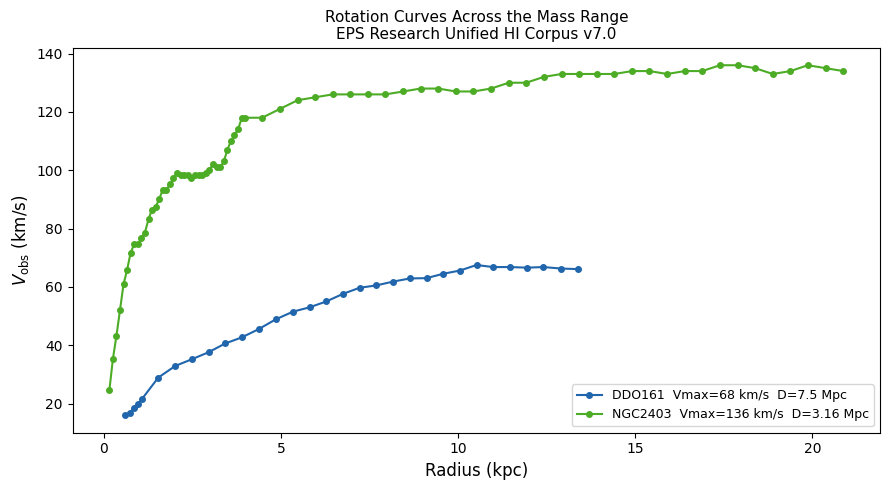

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

targets = ['DDO161', 'NGC2403', 'UGC2885']
colors  = ['#2166ac', '#4dac26', '#d6604d']

fig, ax = plt.subplots(figsize=(9, 5))
for name, color in zip(targets, colors):
    try:
        g = next(g for g in corpus['galaxies'] if g['galaxy'] == name)
        d = g['data']
        R    = [p['Rad']  for p in d]
        Vobs = [p['Vobs'] for p in d]
        ax.plot(R, Vobs, 'o-', color=color, linewidth=1.5, markersize=4,
                label=f'{name}  Vmax={max(Vobs):.0f} km/s  D={g["distance_mpc"]} Mpc')
    except StopIteration:
        print(f"Galaxy {name} not found — check galaxy name in corpus")

ax.set_xlabel('Radius (kpc)', fontsize=12)
ax.set_ylabel(r'$V_{\rm obs}$ (km/s)', fontsize=12)
ax.set_title('Rotation Curves Across the Mass Range\n'
             'EPS Research Unified HI Corpus v7.0', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ex09_multi_galaxy.png', dpi=150, bbox_inches='tight')
plt.show()